In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df=pd.read_csv('/content/drive/MyDrive/Salary_Data (2).csv')
df.head()

,YearsExperience,Age,Salary
0,1.1,21.0,39343
1,1.3,21.5,46205
2,1.5,21.7,37731
3,2.0,22.0,43525
4,2.2,22.2,39891


In [7]:
df.rename(columns={'YearsExperience':'Experience'},inplace=True)
df.head()

,Experience,Age,Salary
0,1.1,21.0,39343
1,1.3,21.5,46205
2,1.5,21.7,37731
3,2.0,22.0,43525
4,2.2,22.2,39891


In [ ]:
df.shape

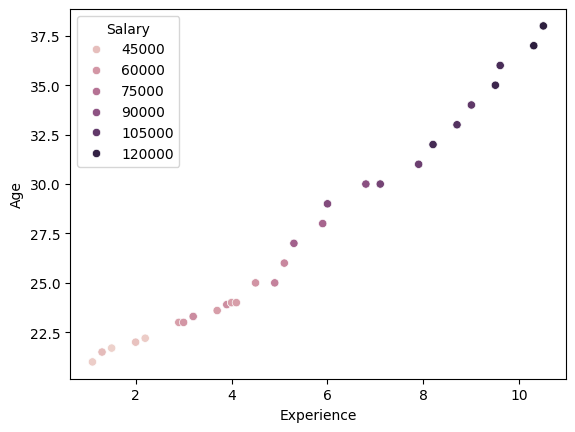

In [24]:
sns.scatterplot(x='Experience',y='Age',hue='Salary',data=df)
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
df.isnull().sum()

,0
Experience,0
Age,0
Salary,0


In [12]:
x=df.drop(columns=['Salary'])
y=df['Salary']

In [13]:
st=StandardScaler()
x=pd.DataFrame(st.fit_transform(x),columns=x.columns)
x

,Experience,Age
0,-1.510053,-1.225076
1,-1.438373,-1.126544
2,-1.366693,-1.087131
3,-1.187494,-1.028012
4,-1.115814,-0.988600
5,-0.864935,-0.830949
6,-0.829096,-0.830949
7,-0.757416,-0.771830
8,-0.757416,-0.771830
9,-0.578216,-0.712712


In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
from sklearn.neighbors import KNeighborsRegressor

In [17]:
knn=KNeighborsRegressor(n_neighbors=3)
knn.fit(x_train,y_train)

KNeighborsRegressor(n_neighbors=3)

In [18]:
knn.score(x_test,y_test)*100

94.07212188647607

In [19]:
knn.score(x_train,y_train)

0.9877813200731872

In [20]:
for i in range(1,20):
  knn1=KNeighborsRegressor(n_neighbors=i)
  knn1.fit(x_train,y_train)
  print(i,knn1.score(x_test,y_test)*100,knn1.score(x_train,y_train)*100)

1 78.81574448805704 99.99262639873075
2 90.61152679575989 98.73605072922047
3 94.07212188647607 98.77813200731872
4 91.21083610592358 98.29523016787115
5 86.84057245865074 97.37741749707037
6 87.03506658406974 97.06715679586956
7 85.48853564518986 95.8993270946898
8 80.75166599912242 94.81089640177089
9 84.04730598924908 92.99107030878568
10 86.53677446335332 90.66945374107979
11 80.53963852155171 88.0219807722515
12 72.45858772821995 83.84292819532969
13 64.55090882455289 79.84588130121428
14 59.085314436560395 75.22220751988203
15 52.8255660276309 70.55382788945994
16 47.22370335919997 66.1958274629056
17 43.146037264848914 61.42542774251633
18 35.94806528895992 55.27839984669449
19 29.491696909228914 49.13820398566461


In [21]:
from mlxtend.plotting import plot_decision_regions

In [ ]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=knn)
plt.show()